In [1]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

In [2]:
sequence = np.array([i for i in range(1, 101)])
print(sequence)


[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]


In [3]:
window_size = 3
# X = inputs/questions
# y = correct answers
X = []
y = []

In [4]:
for i in range(len(sequence) - window_size):
 X.append(sequence[i:i + window_size])
 y.append(sequence[i + window_size])
print("First 5 input examples:")
print(X[:5])
print("First 5 answers:")
print(y[:5])

First 5 input examples:
[array([1, 2, 3]), array([2, 3, 4]), array([3, 4, 5]), array([4, 5, 6]), array([5, 6, 7])]
First 5 answers:
[np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [6]:
X = np.array(X)
y = np.array(y)
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (97, 3)
y shape: (97,)


In [7]:
X = X.reshape((X.shape[0], X.shape[1], 1))
print("New X shape:", X.shape)

New X shape: (97, 3, 1)


In [8]:
model = Sequential()
model.add(SimpleRNN(50, activation='relu', input_shape=(window_size,
1)))
model.add(Dense(1))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.compile(optimizer='adam', loss='mse')

In [11]:
model.fit(X, y, epochs=500, verbose=0)
print("Training complete.")

Training complete.


In [12]:
test_input = np.array([8, 9, 10])
# RNN expects: samples, timesteps, features
test_input = test_input.reshape((1, window_size, 1))
predicted = model.predict(test_input, verbose=0)
print(f"Predicted next number: {predicted[0][0]:.2f}")

Predicted next number: 11.08


In [13]:
predictions = model.predict(X, verbose=0)

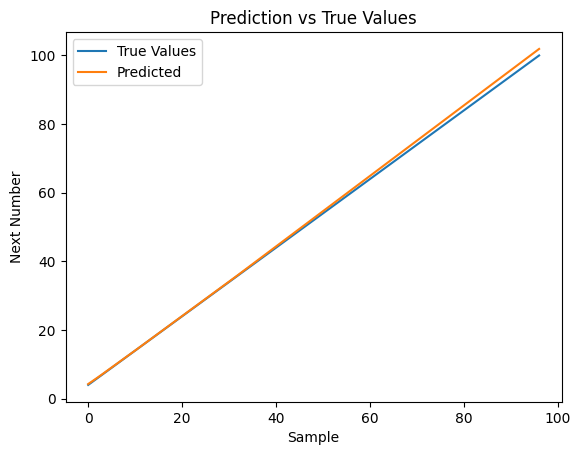

In [14]:
plt.plot(y, label='True Values')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.title("Prediction vs True Values")
plt.xlabel("Sample")
plt.ylabel("Next Number")
plt.show()